In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [3]:
df = load_diabetes(as_frame=True).frame

In [6]:
X = df.drop("target",axis=1)
y = df["target"]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state = 42
)

In [10]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [11]:
from sklearn.metrics import r2_score,mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE train: ",mean_squared_error(y_train,y_pred_train))
print("MSE test: ",mean_squared_error(y_test,y_pred_test))

print("r^2 train: ",r2_score(y_train,y_pred_train))
print("r^2 test: ",r2_score(y_test,y_pred_test))

MSE train 0.0
MSE test 5769.0300751879695
r^2 train 1.0
r^2 test -0.06867380106030452


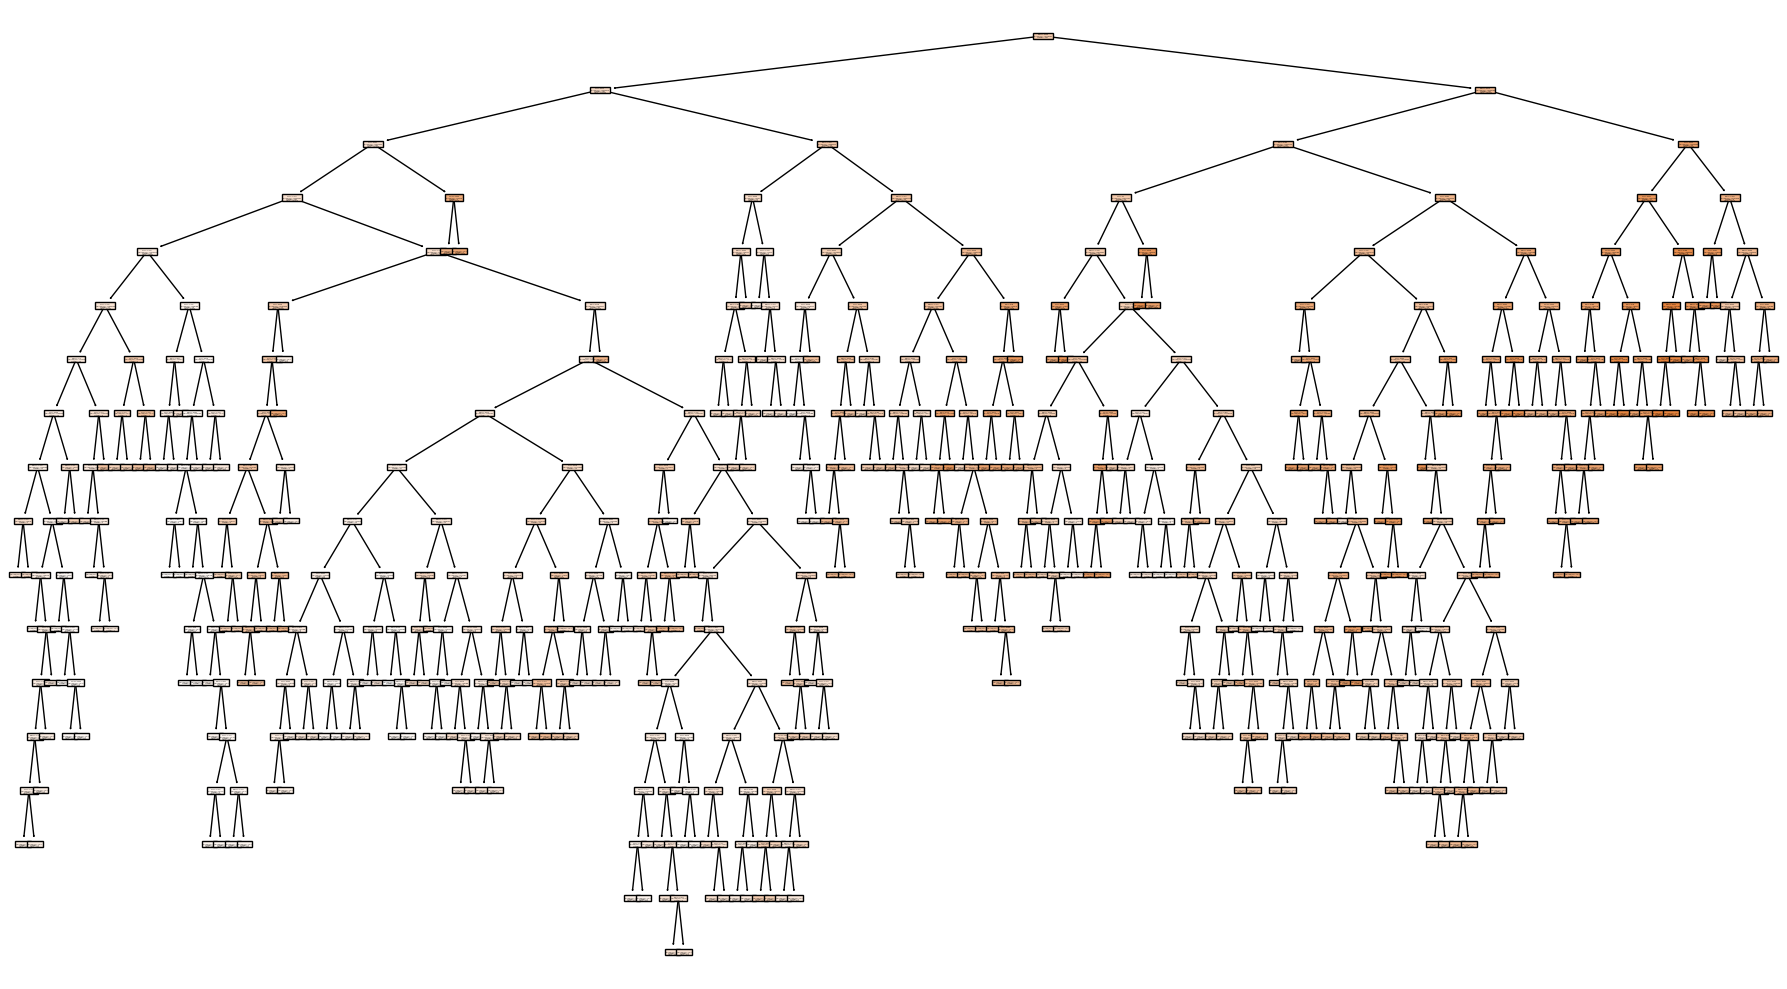

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names = X.columns,
    filled=True,
)
plt.tight_layout()

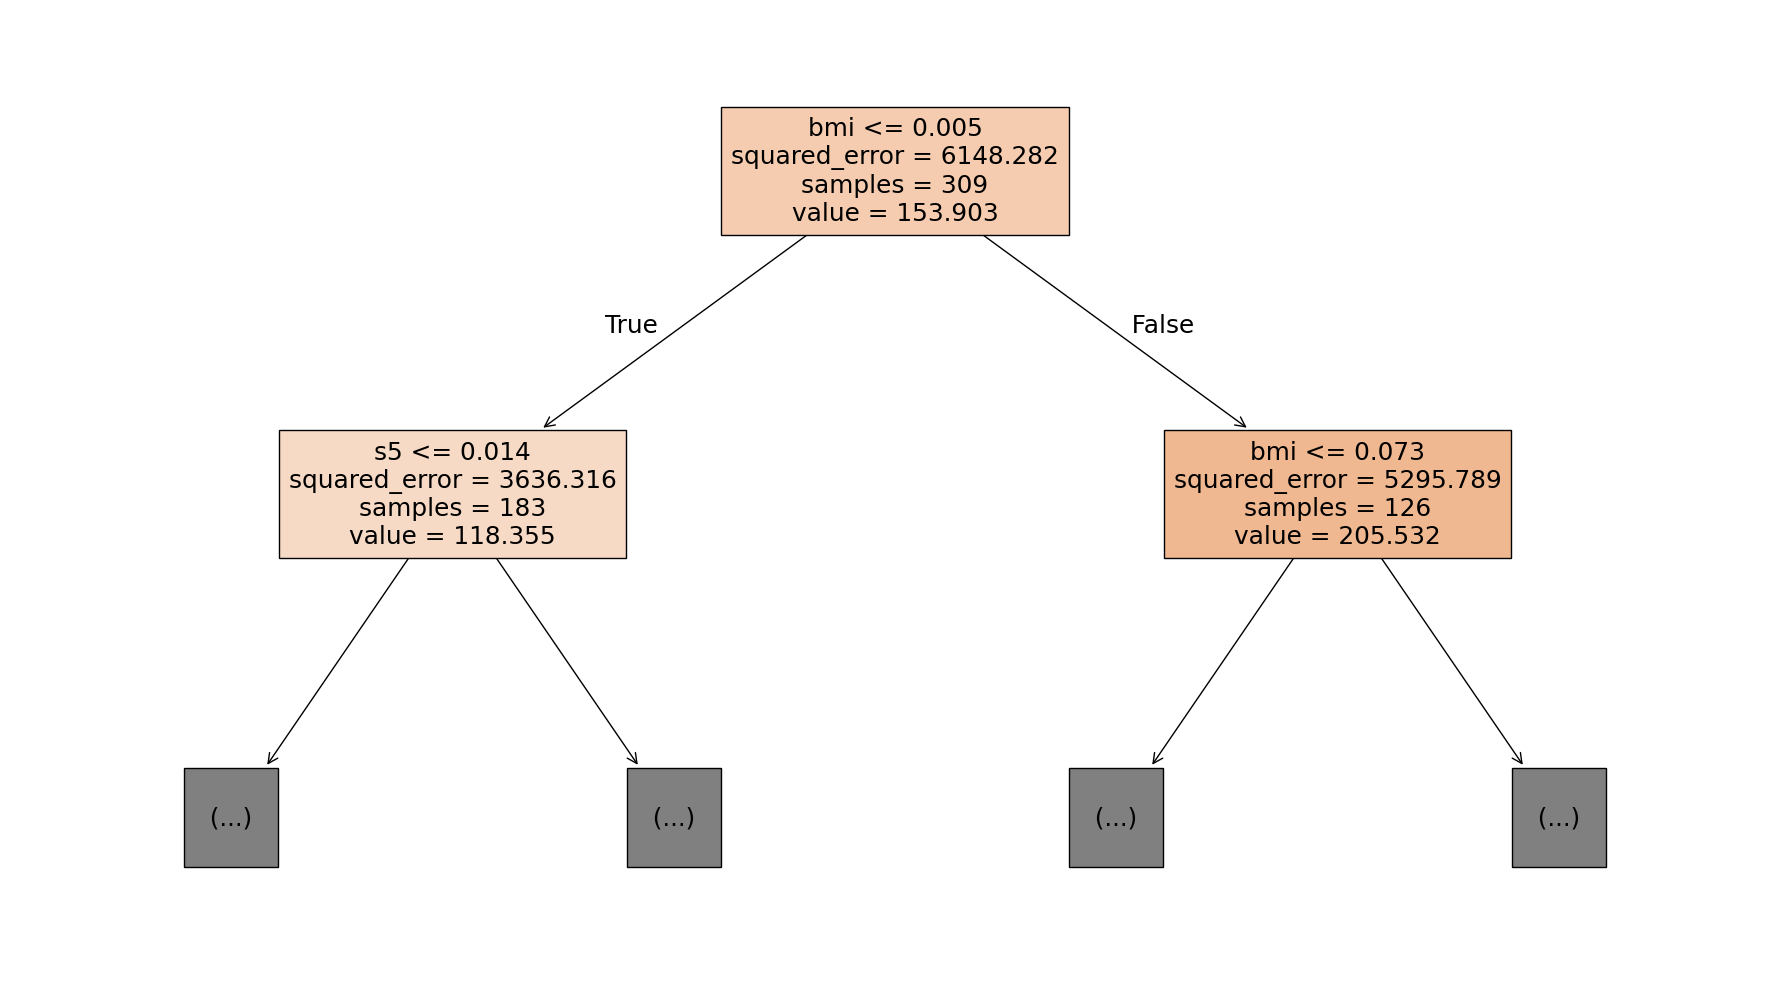

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names = X.columns,
    filled=True,
    max_depth = 1
)
plt.tight_layout()

# Pre-Pruning

In [21]:
max_depth = [1,3,5]

for depth in max_depth:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)

    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(depth)
    print(f"MSE train for depth {depth}: ",mean_squared_error(y_train,y_pred_train))
    print(f"MSE test for depth {depth}: ",mean_squared_error(y_test,y_pred_test))
    
    print(f"r^2 train for depth {depth}: ",r2_score(y_train,y_pred_train))
    print(f"r^2 test for depth {depth}: ",r2_score(y_test,y_pred_test))

    print("\n")
    

1
MSE train for depth 1:  4312.994451728735
MSE test for depth 1:  4280.762895394589
r^2 train for depth 1:  0.2985041078711069
r^2 test for depth 1:  0.20701762770578158


3
MSE train for depth 3:  2918.4746676323302
MSE test for depth 3:  3616.769894653006
r^2 train for depth 3:  0.5253186588715137
r^2 test for depth 3:  0.3300178400000161


5
MSE train for depth 5:  1965.7191227426613
MSE test for depth 5:  3736.1208174871144
r^2 train for depth 5:  0.6802815526158444
r^2 test for depth 5:  0.30790888880668643




In [28]:
min_sample_split = [2, 5, 10]

for mss in min_sample_split:
    model = DecisionTreeRegressor(
        max_depth=2,
        min_samples_split=mss
    )

    model.fit(X_train, y_train)

    # Make predictions for THIS model
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(mss)

    print(
        f"MSE train for min_sample_split {mss}: ",
        mean_squared_error(y_train, y_pred_train)
    )

    print(
        f"MSE test for min_sample_split {mss}: ",
        mean_squared_error(y_test, y_pred_test)
    )

    print(
        f"R² train for min_sample_split {mss}: ",
        r2_score(y_train, y_pred_train)
    )

    print(
        f"R² test for min_sample_split {mss}: ",
        r2_score(y_test, y_pred_test)
    )

    print("\n")

2
MSE train for min_sample_split 2:  3442.4572006557632
MSE test for min_sample_split 2:  3479.644254558814
R² train for min_sample_split 2:  0.44009443737595844
R² test for min_sample_split 2:  0.35541943734175174


5
MSE train for min_sample_split 5:  3442.4572006557632
MSE test for min_sample_split 5:  3479.644254558814
R² train for min_sample_split 5:  0.44009443737595844
R² test for min_sample_split 5:  0.35541943734175174


10
MSE train for min_sample_split 10:  3442.4572006557632
MSE test for min_sample_split 10:  3479.644254558814
R² train for min_sample_split 10:  0.44009443737595844
R² test for min_sample_split 10:  0.35541943734175174




In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

for depth in [2, 3, 4, 5, 6]:
    for mss in [2, 5, 10, 20]:
        
        model = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_split=mss,
            random_state=42
        )
        
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        print(
            f"depth={depth}, mss={mss}, "
            f"Train R²={r2_score(y_train, y_pred_train):.3f}, "
            f"Test R²={r2_score(y_test, y_pred_test):.3f}, "
            f"Test MSE={mean_squared_error(y_test, y_pred_test):.2f}"
        )

depth=2, mss=2, Train R²=0.440, Test R²=0.355, Test MSE=3479.64
depth=2, mss=5, Train R²=0.440, Test R²=0.355, Test MSE=3479.64
depth=2, mss=10, Train R²=0.440, Test R²=0.355, Test MSE=3479.64
depth=2, mss=20, Train R²=0.440, Test R²=0.355, Test MSE=3479.64
depth=3, mss=2, Train R²=0.525, Test R²=0.330, Test MSE=3616.77
depth=3, mss=5, Train R²=0.525, Test R²=0.330, Test MSE=3616.77
depth=3, mss=10, Train R²=0.525, Test R²=0.330, Test MSE=3616.77
depth=3, mss=20, Train R²=0.525, Test R²=0.330, Test MSE=3616.77
depth=4, mss=2, Train R²=0.601, Test R²=0.324, Test MSE=3649.42
depth=4, mss=5, Train R²=0.601, Test R²=0.324, Test MSE=3651.07
depth=4, mss=10, Train R²=0.595, Test R²=0.352, Test MSE=3499.67
depth=4, mss=20, Train R²=0.591, Test R²=0.350, Test MSE=3511.28
depth=5, mss=2, Train R²=0.680, Test R²=0.293, Test MSE=3818.07
depth=5, mss=5, Train R²=0.679, Test R²=0.260, Test MSE=3992.52
depth=5, mss=10, Train R²=0.668, Test R²=0.297, Test MSE=3793.38
depth=5, mss=20, Train R²=0.648, 

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 30}
Best CV R²: 0.3206004385861415
